# MARL DQN Analysis
Episode-level results are saved alongside a JSON manifest for quick loading and plotting.


In [1]:
from pathlib import Path
import sys

try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd()

ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'analysis' else NOTEBOOK_DIR
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from analysis import analysis_utils

DATA_DIR = NOTEBOOK_DIR / 'results'
DATA_DIR.mkdir(exist_ok=True)
FIG_DIR = NOTEBOOK_DIR / 'figures'
FIG_DIR.mkdir(exist_ok=True)

target_res = "5_player_logit_maxprice_4_dqn_baseactions_reset_3_state_avgprice_avglowest_lastlowest_N5_actions0-3-7-11_20251208T150301Z"
TARGET_FIG_DIR = FIG_DIR / target_res
TARGET_FIG_DIR.mkdir(exist_ok=True)

sorted(DATA_DIR.glob('*.json'))[:3]

[PosixPath('/Users/liushijian/Documents/GitHub/Amazon_BuyBox_Reinforcement_Learning/analysis/results/2_player_simplerule_tab_q_2_state_lastown_lastotherlowest_N2_lambda1_rho1-0.9-0.5-0.1-0_20251203T033656Z.json'),
 PosixPath('/Users/liushijian/Documents/GitHub/Amazon_BuyBox_Reinforcement_Learning/analysis/results/5_player_logit_a12_10_dqn_baseactions_reset_3_state_avgprice_avglowest_lastlowest_N5_actions0-1-3-5-7-9-11_20251208T022151Z.json'),
 PosixPath('/Users/liushijian/Documents/GitHub/Amazon_BuyBox_Reinforcement_Learning/analysis/results/5_player_logit_a12_10_grid_20_dqn_baseactions_reset_3_state_avgprice_avglowest_lastlowest_N5_actions0-3-7-11_20251208T024129Z.json')]

In [2]:
target_file = DATA_DIR / f'{target_res}.json'

if not target_file.exists():
    print(f"Experiment file {target_file.name} not found. Run the experiment or update the path above.")
else:
    print(f'Loaded experiment: {target_file.name}')
    experiment = analysis_utils.load_experiment(target_file)
    frame = analysis_utils.runs_to_frame(experiment)
    display(frame.head())


Loaded experiment: 5_player_logit_maxprice_4_dqn_baseactions_reset_3_state_avgprice_avglowest_lastlowest_N5_actions0-3-7-11_20251208T150301Z.json


,scenario,share_parameters,seed,episode,mean_profit,avg_price,avg_lowest_price,repricer_share,network_density,weighted_density,...,action_share_undercut_reset,action_share_undercut_reset_raise,action_share_match,action_share_match_raise,action_share_match_reset,action_share_match_reset_raise,action_share_above,action_share_above_raise,action_share_above_reset,action_share_above_reset_raise
0,independent_agents,False,0,0.0,0.089072,1.701025,1.405226,1.0,0.80,0.217391,...,0.4,0.0,0.0,0.0,0.4,0.0,0.0,0.0,0.2,0.0
1,independent_agents,False,0,1.0,0.120404,1.823665,1.589883,0.6,0.20,0.135135,...,0.4,0.0,0.0,0.0,0.2,0.0,0.0,0.0,0.0,0.0
2,independent_agents,False,0,2.0,0.095704,1.518807,1.410452,0.6,0.25,0.103061,...,0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.4,0.0
3,independent_agents,False,0,3.0,0.116978,1.687089,1.494070,0.2,0.00,0.000000,...,0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,independent_agents,False,0,4.0,0.099608,1.526124,1.452261,1.0,0.40,0.204082,...,0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.8,0.0


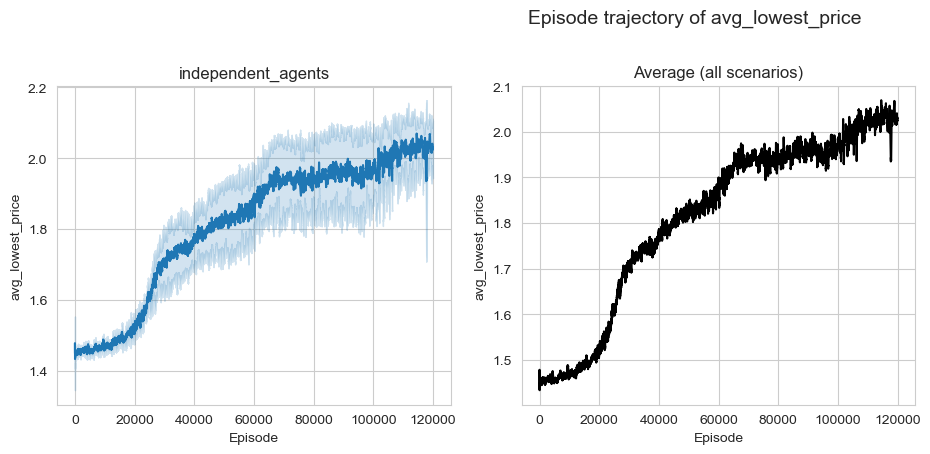

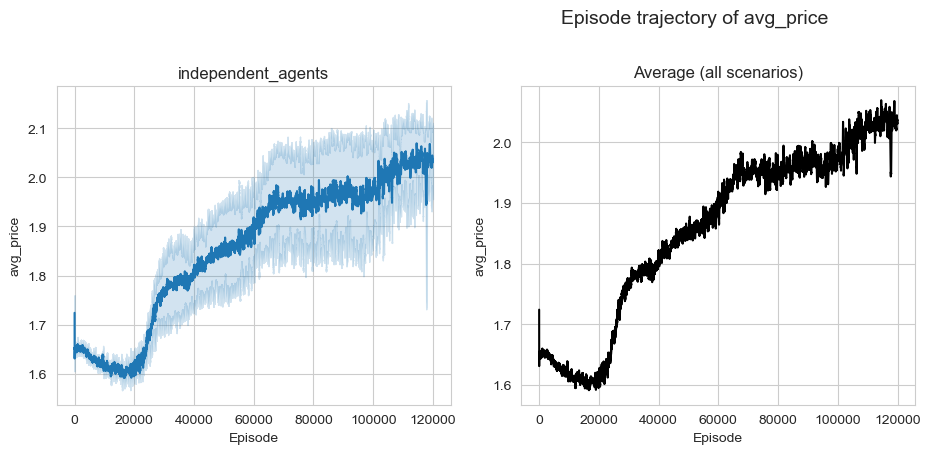

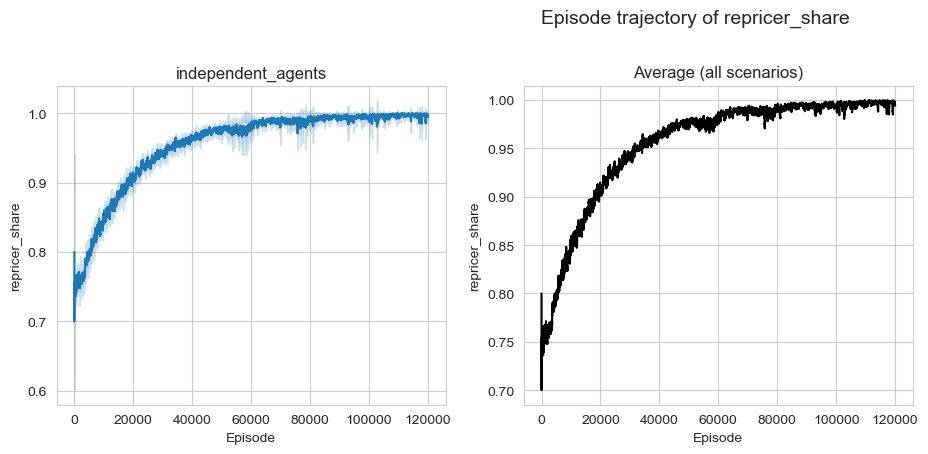

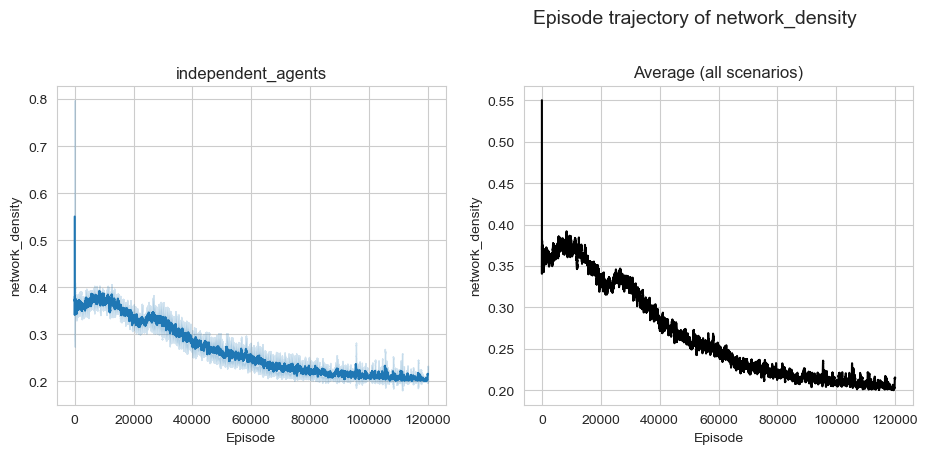

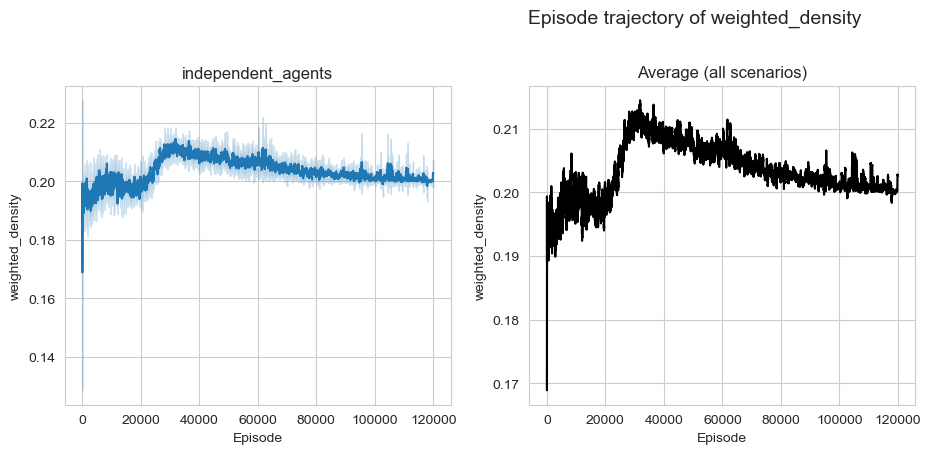

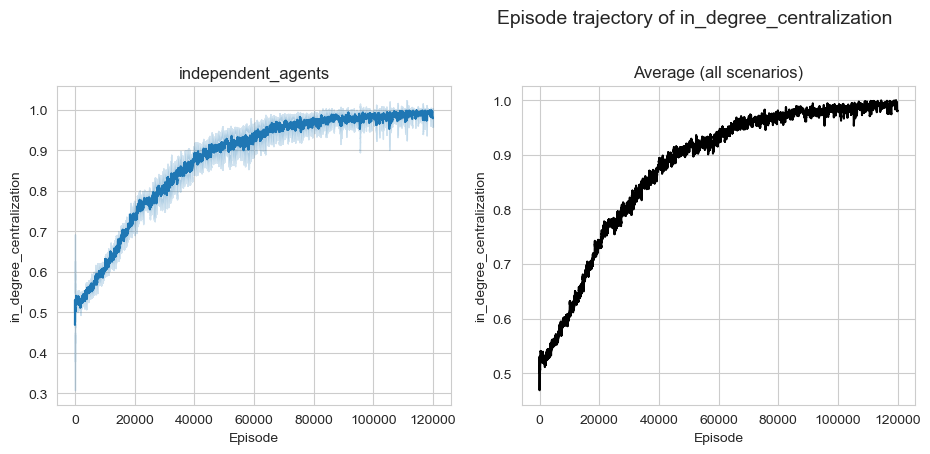

In [3]:
if 'frame' in globals():
    metrics = [
        'avg_lowest_price',
        'avg_price',
        # 'mean_profit',
        'repricer_share',
        'network_density',
        'weighted_density',
        'in_degree_centralization',
        # 'weighted_in_degree_centralization',
    ]
    for metric in metrics:
        analysis_utils.plot_metric_over_episodes(
            frame,
            metric,
            smoothing=200,
            use_log_x=False,
            title=f'Episode trajectory of {metric}',
            save_path=TARGET_FIG_DIR / f'{metric}_episodes.png',
        )

In [4]:
# if 'frame' in globals():
#     final_metrics = [
    #     'avg_lowest_price',
    #     'mean_profit',
    #     'repricer_share',
    #     'network_density',
    #     'weighted_density',
    #     'in_degree_centralization',
    #     'weighted_in_degree_centralization',
    # ]
    # for metric in final_metrics:
    #     analysis_utils.plot_final_metric(
    #         frame,
    #         metric,
    #         tail_length=1000,
    #         save_path=TARGET_FIG_DIR / f'{metric}_final.png',
    #     )

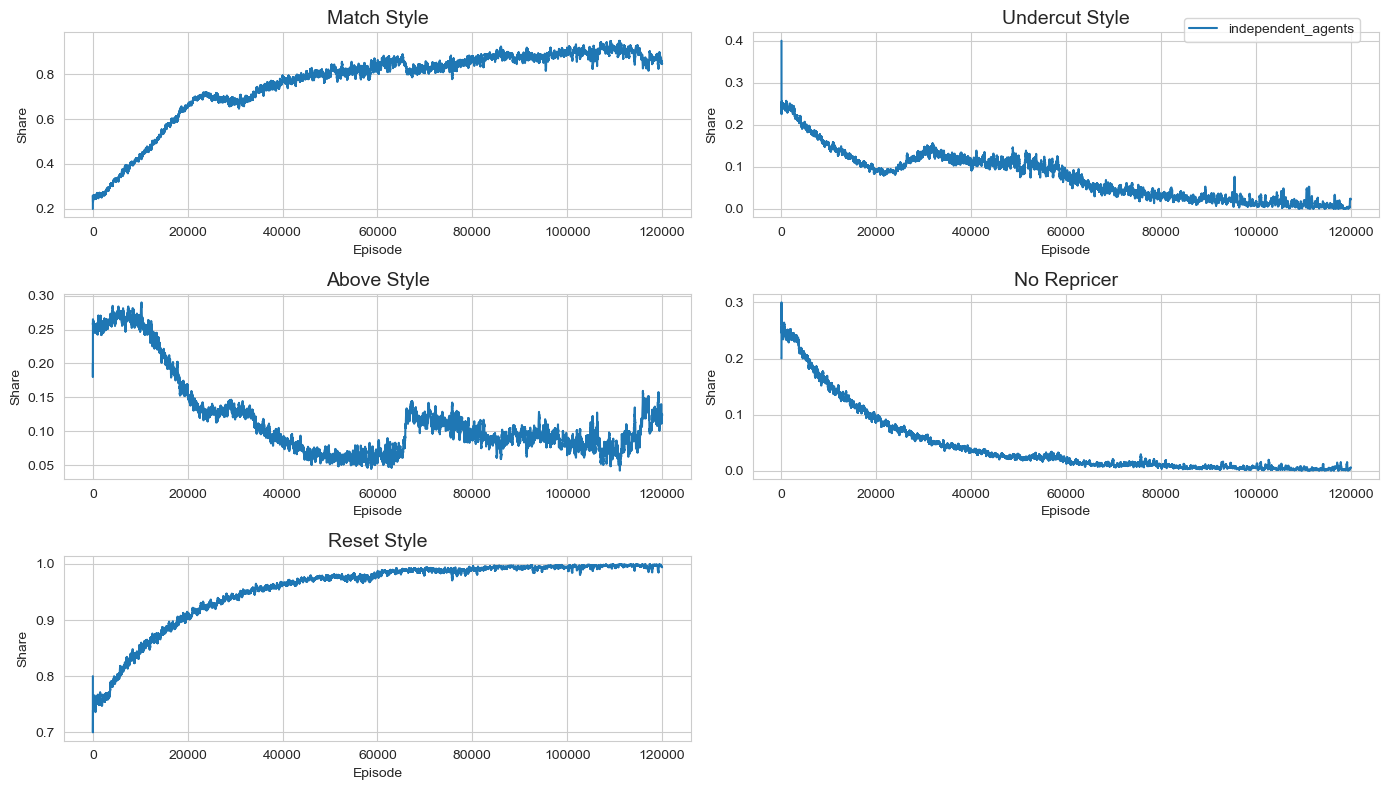

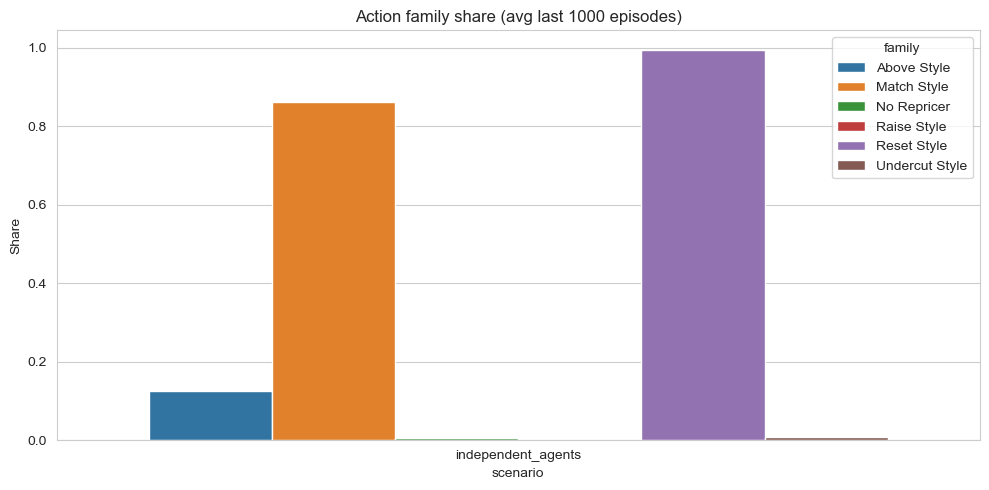

In [5]:
if 'frame' in globals():
    analysis_utils.plot_action_family_shares(
        frame,
        use_log_x=False,
        smoothing=200,
        # families=["Match Style", "Undercut Style", "Above Style", "No Repricer" , 'Raise Style', 'Reset Style'],
        families=["Match Style", "Undercut Style", "Above Style", "No Repricer" , 'Reset Style'],
        layout=(3, 2),
        save_path=TARGET_FIG_DIR / 'action_family_over_episodes.png',
    )
    analysis_utils.plot_final_action_family_shares(
        frame,
        tail_length=1000,
        save_path=TARGET_FIG_DIR / 'action_family_final.png',
    )